# **Source Modelling - Energy Bands Approach**

In [ ]:
# NOTE:
#  - this NB aims to analyse how good a SINGLE source is well modelled in a GIVEN energy range
#  - the modelling is performed by accounting for the DETECTOR SPATIAL RESOLUTION effects in the given energy range,
#    provided the trend of the kernel parameters (HERE: `alpha` is variable wrt the energy, while `beta` is fixed)
#  - here the FLEXIBLE source model is used to allow for custom vignetting and PSFY effects

from singleCAM_IROS._pipeline_support import _handle_dirpaths
from typing import Any, Callable

from pathlib import Path

from numpy.typing import NDArray
import numpy as np
from astropy.io.fits.fitsrec import FITS_rec

from bloodmoon.coords import equatorial2shift
from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask, count, decode
from bloodmoon.images import argmax

import darksun as ds

ds.show.set_figures_darkbkg()

**Load Mask Pattern and Obs Data**

In [2]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

# SKYFIELD: str = "IROSDummy"
# DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_infdet_1ks"
SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"

UPS_X: int = 8
UPS_Y: int = 4

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)


# data from camera A
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
sdlA_detct = ds.get_data(filepaths[ID_CAMERA_A]['detected'])
sdlA_recnstr = ds.get_data(filepaths[ID_CAMERA_A]['reconstructed'])

## data from camera B
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
sdlB_detct = ds.get_data(filepaths[ID_CAMERA_B]['detected'])
sdlB_recnstr = ds.get_data(filepaths[ID_CAMERA_B]['reconstructed'])

**Source Model**

In [ ]:
from flexible_source_model import model_sky as gen_sky_model

<br>

<br>

- Let's test the approach:

    * working logic for instrumental effects
    * differences with default `bloodmoon` model (with internal vignetting and detector spatial res implementations)

In [5]:
# methods for data gathering (source RA/Dec coords from catalogue and detected photons in given energy range)

from bloodmoon.types import CoordEquatorial
from darksun.benchmarking import source_catalogue_data
from darksun.data import DataLoader, CatalogueLoader

type EnergyRange = tuple[float, float]


def get_source_coords(
    sourceID: str,
    catalogue: CatalogueLoader,
) -> CoordEquatorial:
    """Extracts the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def filter_energy(
    photons: FITS_rec,
    eband: EnergyRange,
) -> FITS_rec:
    """Filters the input photons by energy, in [keV]."""
    E_min, E_max = eband
    return ds.filter_data(photons, E_min=E_min, E_max=E_max, coords=None)

In [ ]:
# methods for detector spatial resolution kernel setup (comp alpha parameter and config effect func)
from scipy.signal import convolve

def get_kernel_alpha_param(
    evalues: NDArray,
    alpha_model: Callable[[NDArray, Any], NDArray],
    model_params: dict[str, float],
) -> float:
    """
    Computes kernel alpha value in given energy band by integral mean.\n
    CFR with: `demo_detector_spatial_res_KernelSingleParams.ipynb`, last cells.
    """
    def integral_mean(y: NDArray, x: NDArray) -> float:
        """Performs the integral mean of `y` wrt input `x` values."""
        return np.sum(y[:-1] * np.diff(x)) / (x[-1] - x[0])
    
    alpha: NDArray = alpha_model(evalues, **model_params)
    avg = integral_mean(alpha, evalues)
    return avg


def config_detectorSpatialRes_effect(
    alpha: float,
    beta: float,
) -> Callable[[CodedMaskCamera, NDArray], NDArray]:
    """
    Configures detector spatial resolution effect application func from given kernel params.
    """
    def modsech(x: NDArray, a0: float, a1: float) -> NDArray:
        """Template for detector spatial resolution kernel."""
        return 1.0 / np.cosh(np.abs(x / a0) ** a1)

    def compute_kernel(x: NDArray) -> NDArray:
        """Computes the LEM-X detector spatial resolution kernel."""
        template = modsech(x, alpha, beta)
        kernel = template.reshape(len(x), -1)
        return kernel / np.sum(kernel)
    
    def psfy(camera: CodedMaskCamera, shadowgram: NDArray) -> NDArray:
        """Applies detector spatial resolution effect to given shadowgram."""
        # compute detector spatial resolution kernel
        px_ydim = camera.specs.mask_deltay / camera.upscale_f.y
        slit_dim = camera.specs.slit_deltay
        bins = np.linspace(-slit_dim, slit_dim, int(2 * slit_dim / px_ydim) + 1)
        kernel = compute_kernel(bins)
        # apply effect
        sg_ = convolve(shadowgram, kernel, mode="same")
        return sg_
    
    return psfy

**Testing Detector Spatial Resolution Effects with Energy Band Approach**

In [12]:
sourceID: str = 'scox1'

coords: CoordEquatorial = get_source_coords(sourceID, catalogueA)
phs: FITS_rec = ds.select_source_photons(coords, sdlA_recnstr.DLdata, False)

In [34]:
eband: EnergyRange = (2.0, 6.0)  # [keV]

eband_phs: FITS_rec = filter_energy(phs, eband)
shift_x, shift_y = equatorial2shift(sdlA_recnstr, wfm, coords.ra, coords.dec)

reconstructed: NDArray = count(wfm, eband_phs)[0]
sky_reconstructed = decode(wfm, reconstructed)

print(f'Number of photons: {reconstructed.sum()}')

Number of photons: 757766.0


In [35]:
# recover PSFY kernel parameters and init effect func

def _comp_evals(eband: EnergyRange, sampling: int = 101) -> NDArray:
    """Quick energy values init for alpha exp model."""
    return np.log(np.logspace(*eband, sampling, base=np.e))

def alpha_model(energy: NDArray, a: float, b: float, c: float) -> NDArray:
    """Model for PSFY kernel alpha parameter."""
    # energy array is centered around 2keV (bottom lim of LEM-X cameras)
    t = np.pow(b * (energy - 2), c)
    pred = a * np.exp(-t)
    return pred

# alpha model fitted parameters (from `demo_detector_spatial_res_KernelSingleParams.ipynb`)
PARAMS: dict[str, float] = {
    'a': 1.2702015,
    'b': 0.1901737,
    'c': 0.6711220,
}

_evals: NDArray = _comp_evals(eband, 10001)
alpha: float = get_kernel_alpha_param(_evals, alpha_model, PARAMS)

print(
    f'Alpha val in {eband} keV: {alpha}\n'
)

psfy: Callable[[CodedMaskCamera, NDArray], NDArray] = config_detectorSpatialRes_effect(alpha, beta=0.85)


skymodel: NDArray = gen_sky_model(wfm, shift_x, shift_y, 1, psfy=psfy)
bm_model = gen_sky_model(wfm, shift_x, shift_y, 1)

Alpha val in (2.0, 6.0) keV: 0.79097214707716



In [36]:
CTS: float = sky_reconstructed.max() + 29070 + 1710 + 27140 + 1800 + 6e3

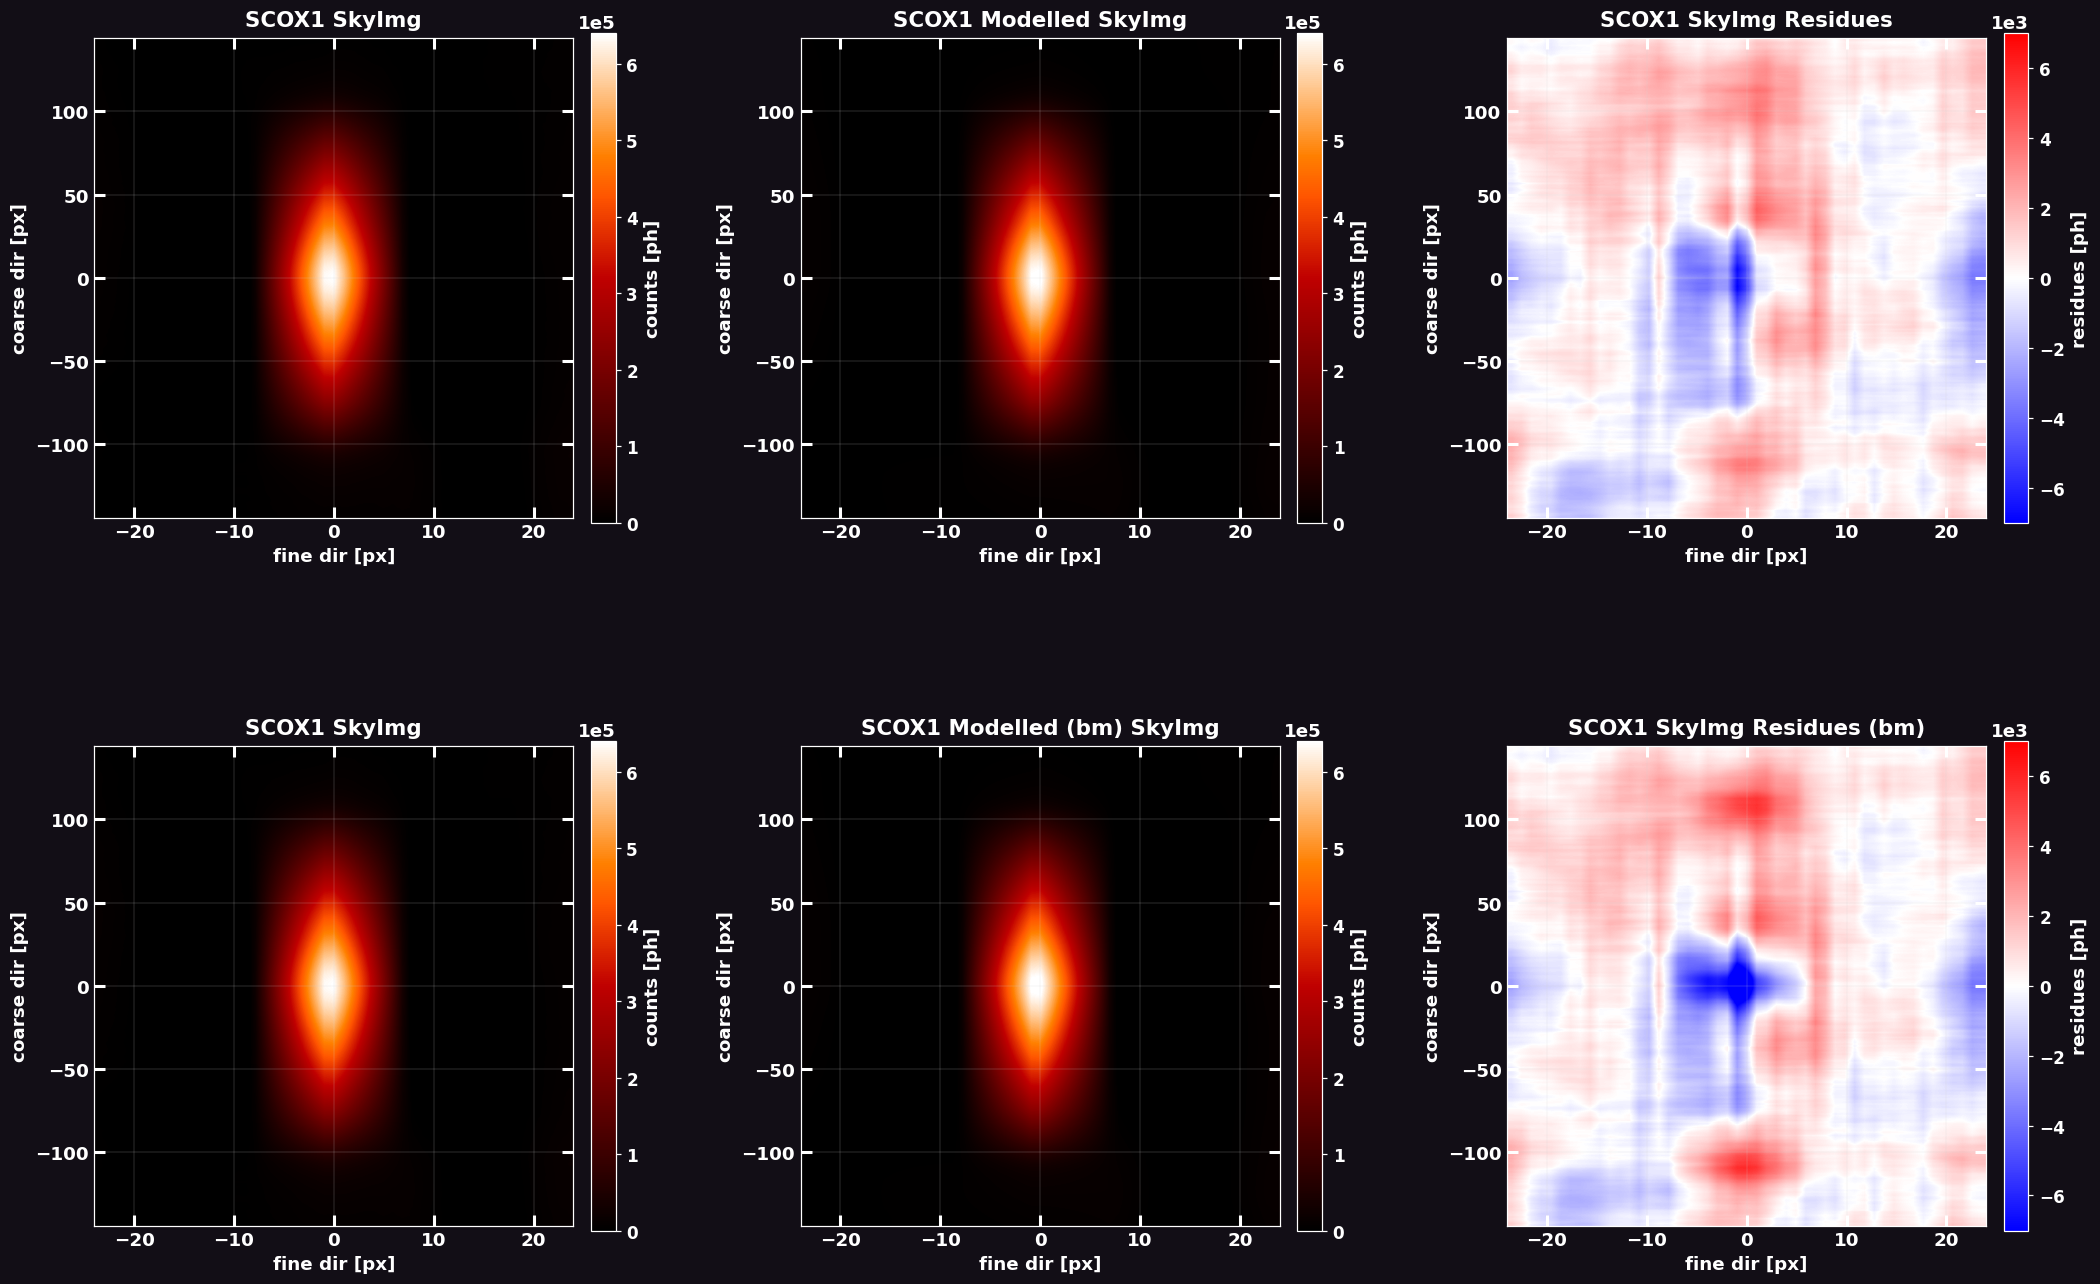

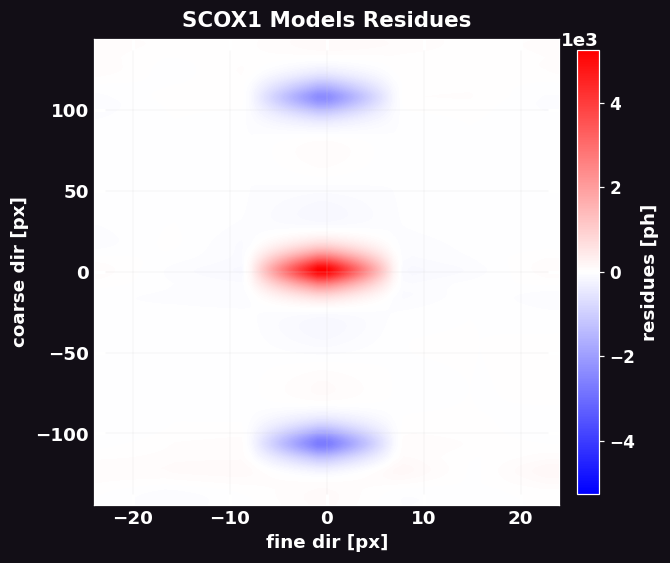

In [37]:
# Sky Images Plots
pos = argmax(sky_reconstructed)
offset = (
    5 * wfm.upscale_f.y,
    2 * wfm.upscale_f.x,
)
_fine, _coarse = ds.psf_extension(wfm)
crp = (
    _coarse + offset[0], _fine + offset[1],
)

skymodel_, bm_model_ = map(lambda x: CTS * x, (skymodel, bm_model))


skycrp, modelcrp, bm_modelcrp = map(
    lambda x: ds.crop(x, pos, crp), (sky_reconstructed, skymodel_, bm_model_),
)

_labels: dict = {
    'xlabel': 'fine dir [px]',
    'ylabel': 'coarse dir [px]',
    'cbarlabel': 'counts [ph]',
}
_imgkwargs: dict = {
    'aspect': crp[1] / crp[0],
    'extent': [-crp[1], crp[1], -crp[0], crp[0]],
    'vmin': 0.0,
    'vmax': skycrp.max(),
    'cmap': 'gist_heat',
    'interpolation': 'bilinear',
}
res = skycrp - modelcrp
vlim = np.max(np.abs(res))

sky_dmaps = (
    ds.map4image(
        img=skycrp,
        title=f'{sourceID.upper()} SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=modelcrp,
        title=f'{sourceID.upper()} Modelled SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=res,
        title=f'{sourceID.upper()} SkyImg Residues',
        xlabel=_labels['xlabel'],
        ylabel=_labels['ylabel'],
        cbarlabel='residues [ph]',
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

bm_res = skycrp - bm_modelcrp
bm_dmaps = (
    ds.map4image(
        img=skycrp,
        title=f'{sourceID.upper()} SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=bm_modelcrp,
        title=f'{sourceID.upper()} Modelled (bm) SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=bm_res,
        title=f'{sourceID.upper()} SkyImg Residues (bm)',
        xlabel=_labels['xlabel'],
        ylabel=_labels['ylabel'],
        cbarlabel='residues [ph]',
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

ds.image_plot(
    dmaps=(*sky_dmaps, *bm_dmaps),
    ncols=3,
    nrows=2,
)

models_res = res - bm_res
vlim = np.max(np.abs(models_res))
ds.image_plot(
    ds.map4image(
        img=models_res,
        title=f'{sourceID.upper()} Models Residues',
        xlabel=_labels['xlabel'],
        ylabel=_labels['ylabel'],
        cbarlabel='residues [ph]',
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

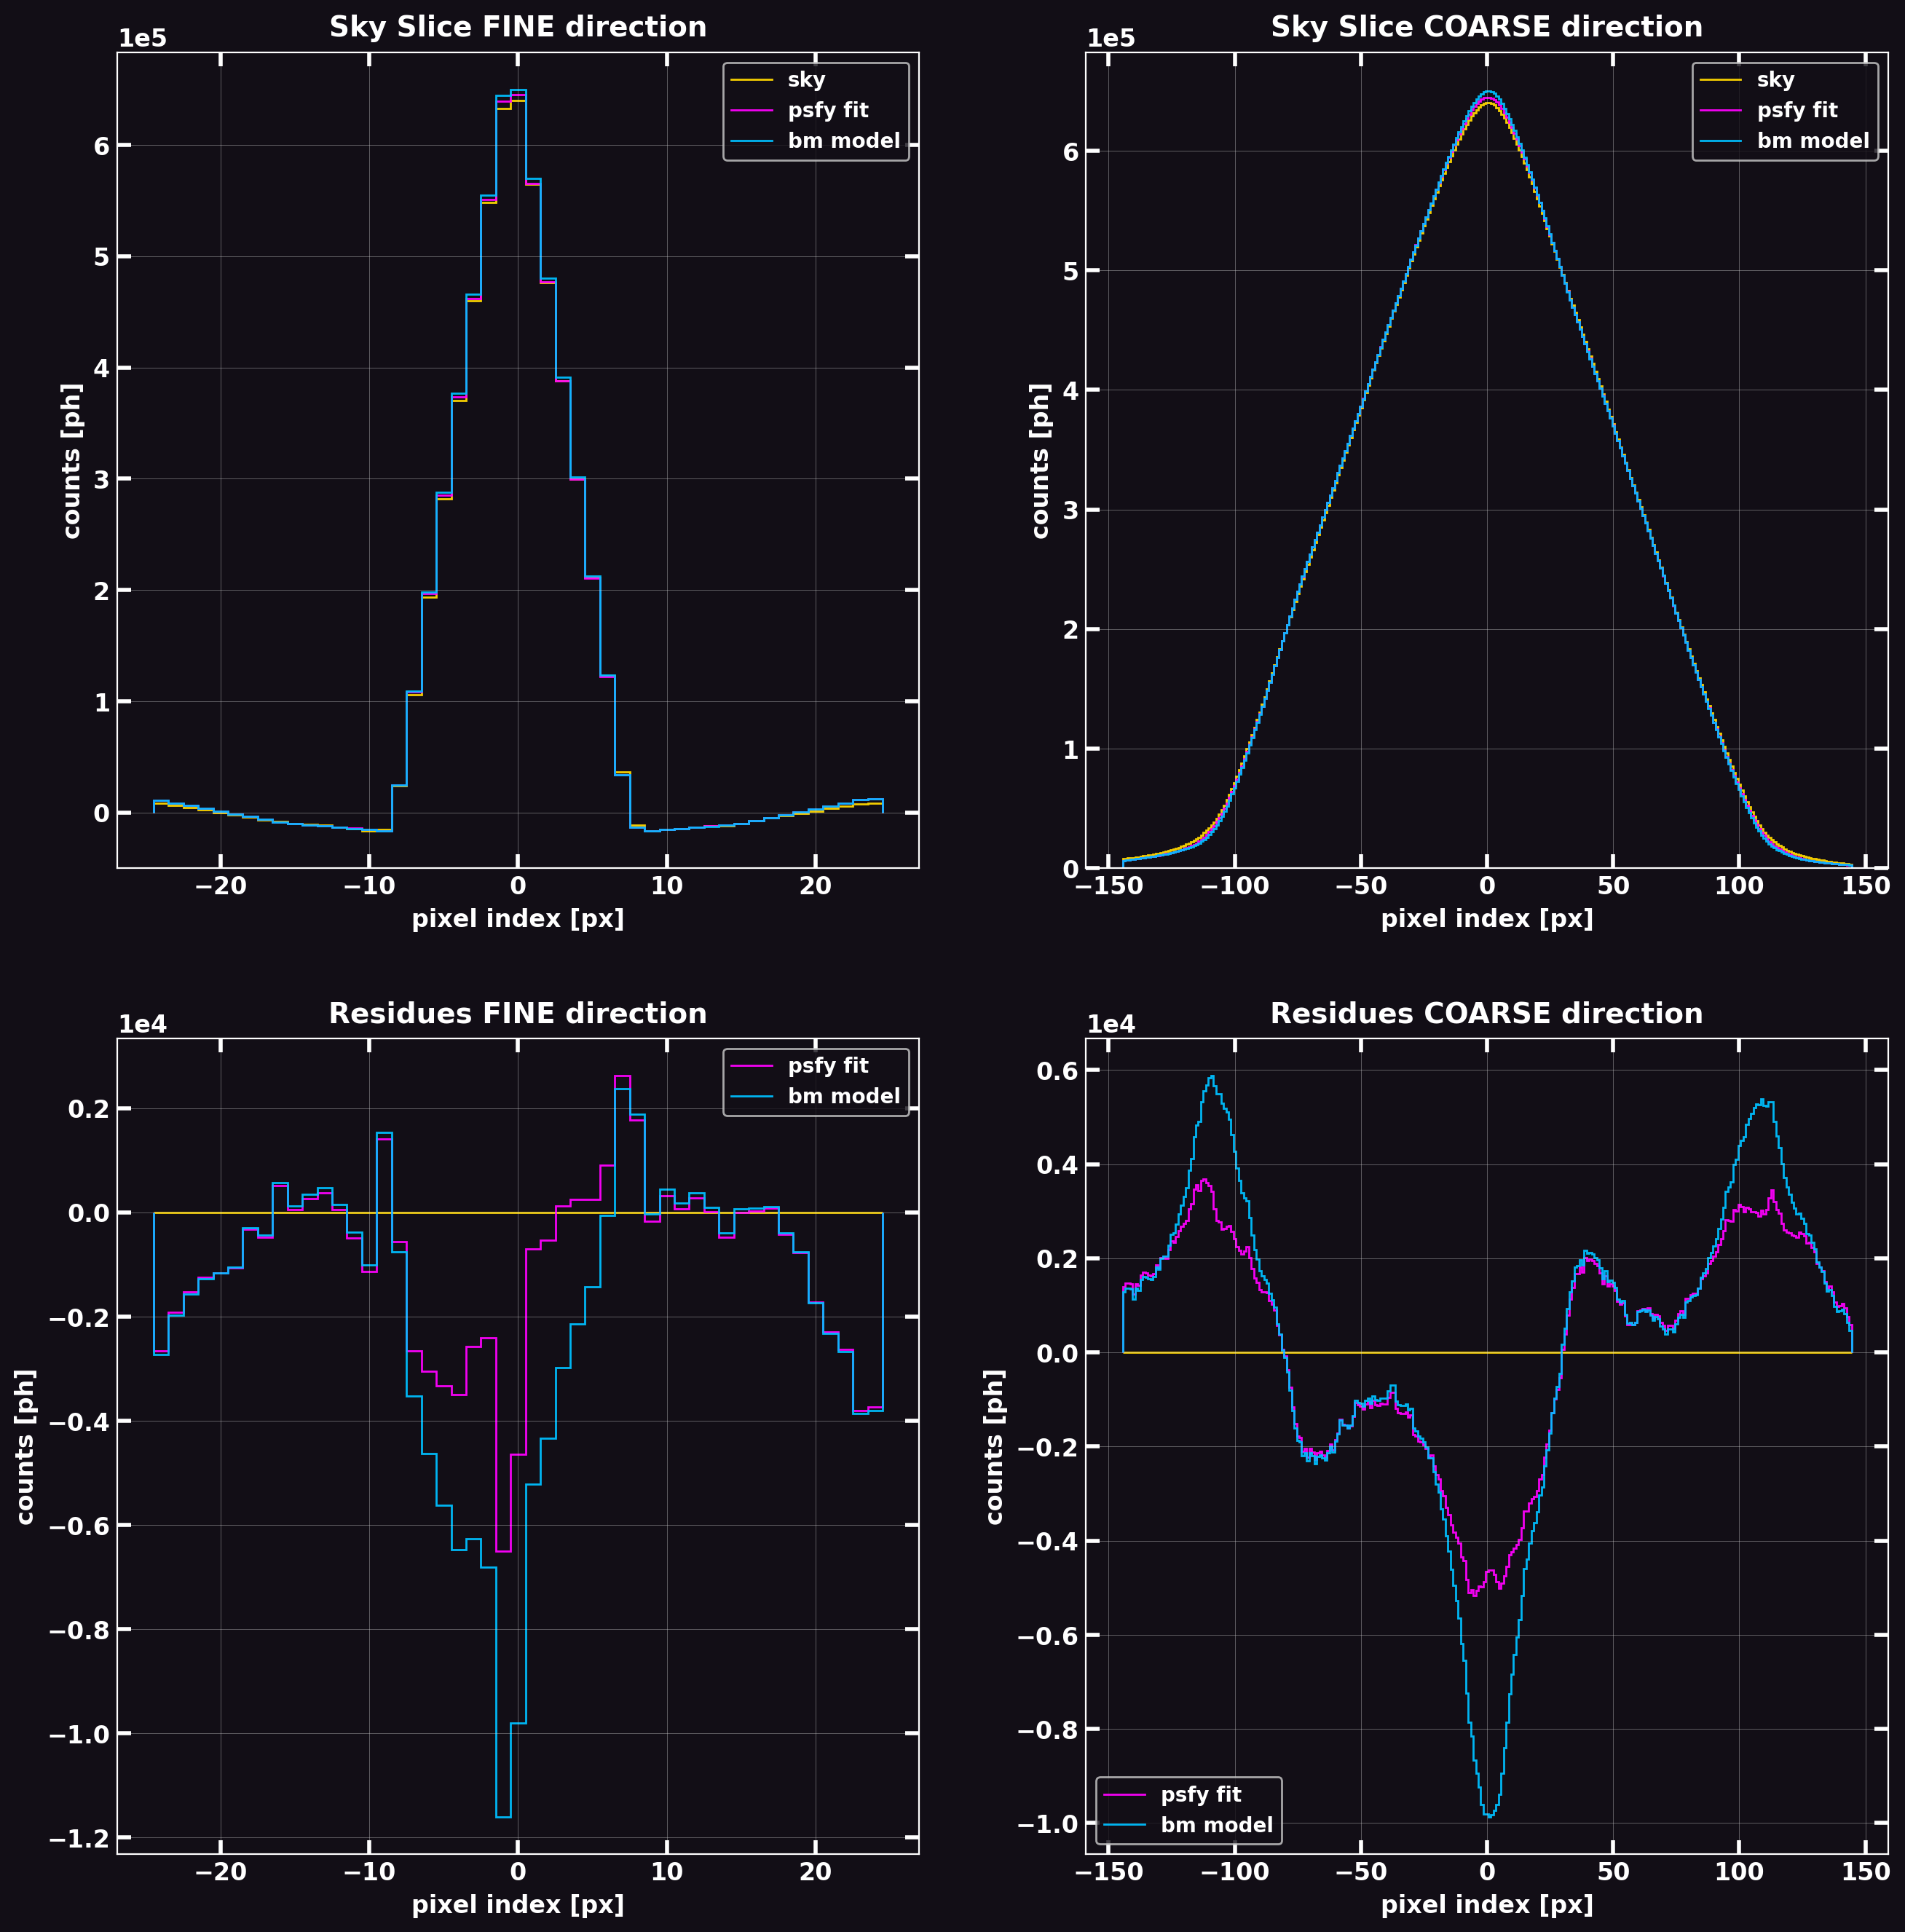

In [41]:
# Profiles Plots
def extract_profile(arr: NDArray, pos: tuple[int, int] | None = None) -> NDArray:
    """Extracts the profile of the input array at given pos."""
    i, j = (
        pos if pos is not None
        else tuple((s - 1) // 2 for s in arr.shape)
    )
    return arr[i, :], arr[:, j]


SHOW_PERC_RES: bool = False


arrs = (skycrp, modelcrp, bm_modelcrp)
clps_x, clps_y = zip(
    *tuple(extract_profile(arr) for arr in arrs)
)

res_, bm_res_ = (
    map(lambda x: x * 100 / skycrp.max(), (res, bm_res)) if SHOW_PERC_RES
    else (res, bm_res)
)
res_arrs = (np.zeros_like(res), res_, bm_res_)
res_clps_x, res_clps_y = zip(
    *tuple(extract_profile(arr) for arr in res_arrs)
)

_get_phase: Callable[[NDArray], NDArray] = lambda x: np.arange(len(x) + 1) - len(x) // 2 - 0.5
_labels: dict = {
    'xlabel': 'pixel index [px]',
    'ylabel': 'counts [ph]',
    'labels': ('sky', 'psfy fit', 'bm model'),
    'color': ('Gold', 'Fuchsia', 'DeepSkyBlue'),
    'style': 'stairs',
}
dmap_clps_x = ds.map4plot(
    arrs=clps_x,
    title='Sky Slice FINE direction',
    x=_get_phase(clps_x[0]),
    **_labels,
)
dmap_clps_y = ds.map4plot(
    arrs=clps_y,
    title='Sky Slice COARSE direction',
    x=_get_phase(clps_y[0]),
    **_labels,
)

_labels['labels'] = ('', 'psfy fit', 'bm model')
if SHOW_PERC_RES:
    _labels['ylabel'] = ('residues wrt sky peak [%]')
res_dmap_clps_x = ds.map4plot(
    arrs=res_clps_x,
    title='Residues FINE direction',
    x=_get_phase(clps_x[0]),
    **_labels,
)
res_dmap_clps_y = ds.map4plot(
    arrs=res_clps_y,
    title='Residues COARSE direction',
    x=_get_phase(clps_y[0]),
    **_labels,
)
ds.plot(
    dmaps=(
        dmap_clps_x, dmap_clps_y,
        res_dmap_clps_x, res_dmap_clps_y,
    ),
    ncols=2,
    nrows=2,
)

In [ ]:
def get_resval(x: NDArray) -> float:
    """Computes central sky residues value in [counts] from percentages array."""
    return x[len(x - 1) // 2] * skycrp.max() / 100

get_resval(res_clps_x[1]), get_resval(res_clps_y[1])

(np.float64(-29767568.941910166), np.float64(-29767568.941910166))